# Лабораторная работа 5: Анимация качения треугольника Рело по квадрату

Решение заданий 5.1–5.3 в одном ноутбуке без создания дополнительных модулей.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

In [26]:
def regular_polygon_relo(
    n: int = 3,
    center: np.ndarray = np.array([0.0, 0.0]),
    r: float = 1.0,
    N: int = 100,
) -> np.ndarray:
    """Return the boundary coordinates of a regular Relo polygon.

    Parameters
    ----------
    n : int
        Number of vertices of the base regular polygon. Must be odd and > 2.
    center : np.ndarray
        Coordinates of the polygon center.
    r : float
        Width of the regular Relo polygon.
    N : int
        Number of points used to describe each side.

    Returns
    -------
    np.ndarray
        Array of shape (n * N, 2) with the boundary points.
    """
    assert isinstance(n, int) and n > 2 and n % 2 == 1, 'n must be an odd integer greater than 2'
    assert isinstance(center, np.ndarray) and center.shape == (2,), 'center must be a 2-element ndarray'
    assert isinstance(r, (int, float)) and r > 0, 'r must be positive'
    assert isinstance(N, int) and N > 0, 'N must be a positive integer'

    l = float(r)
    R = l / (2 * np.sin(np.pi / n))
    t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
    alpha = 2 * np.pi / n
    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    list_sides = [
        vertices[i] + r * np.transpose([
            np.cos(np.pi + angle + i * alpha),
            np.sin(np.pi + angle + i * alpha),
        ])
        for i in range(n)
    ]

    return np.concatenate(list_sides)

## Задание 5.1. Начальное положение треугольника Рело и квадрата

Построим начальное расположение треугольника Рело и квадрата стороны `r` с центром в начале координат.

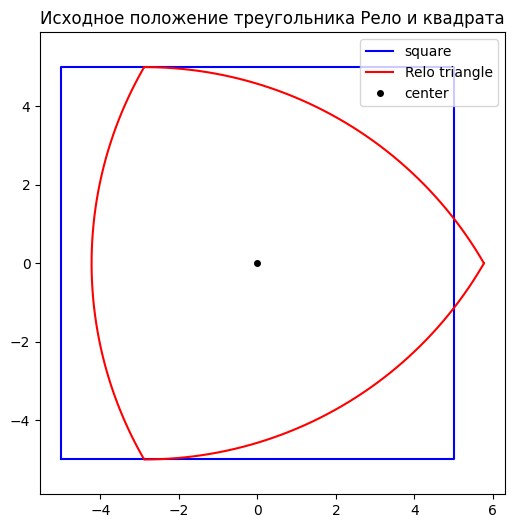

In [27]:
n = 3
center = np.array([0.0, 0.0])
r = 10.0
N = 100

relo_matrix = regular_polygon_relo(n=n, center=center, r=r, N=N)
square = np.array([
    [-r/2, -r/2],
    [r/2, -r/2],
    [r/2, r/2],
    [-r/2, r/2],
    [-r/2, -r/2],
])

plt.figure(figsize=(6, 6))
plt.plot(square[:, 0], square[:, 1], 'b-', label='square')
plt.plot(relo_matrix[:, 0], relo_matrix[:, 1], 'r-', label='Relo triangle')
plt.plot(center[0], center[1], 'k.', markersize=8, label='center')
plt.axis('equal')
plt.title('Исходное положение треугольника Рело и квадрата')
plt.legend()

Вектор сдвига `shift` вычисляется как разность между правой границей треугольника Рело и правой границей квадрата.
Поскольку правая граница Relo при начальном расположении равна радиусу описанной окружности `R`, а правая граница квадрата равна `r/2`,
то `shift = np.array([R - r/2, 0])`.
Это гарантирует, что при сдвиге влево край Relo будет касаться правой стороны квадрата.

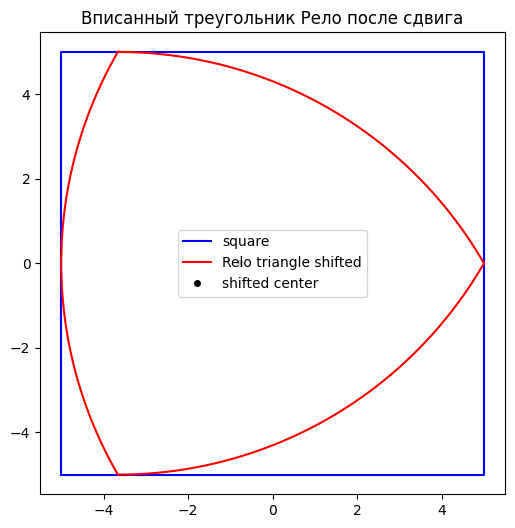

In [28]:
R = r / (2 * np.sin(np.pi / n))
shift = np.array([R - r / 2, 0.0])
relo_matrix_shifted = relo_matrix - shift
center_shifted = center - shift

plt.figure(figsize=(6, 6))
plt.plot(square[:, 0], square[:, 1], 'b-', label='square')
plt.plot(relo_matrix_shifted[:, 0], relo_matrix_shifted[:, 1], 'r-', label='Relo triangle shifted')
plt.plot(center_shifted[0], center_shifted[1], 'k.', markersize=8, label='shifted center')
plt.axis('equal')
plt.title('Вписанный треугольник Рело после сдвига')
plt.legend()

## Задание 5.2. Анимация поступательного движения

Центр треугольника Рело движется по окружности радиуса `shift[0]` против часовой стрелки от `-π` до `π`.

In [29]:
def draw_frame_translation(r: float, N_frames: int, frame: int = 0) -> None:
    """Draw a single translation frame of the Relo triangle.

    Parameters
    ----------
    r : float
        Width of the Relo triangle.
    N_frames : int
        Total number of animation frames.
    frame : int, optional
        Frame index to display, by default 0.
    """
    n_local = 3
    N_side = 100
    center_local = np.array([0.0, 0.0])
    square_local = np.array([
        [-r / 2, -r / 2],
        [r / 2, -r / 2],
        [r / 2, r / 2],
        [-r / 2, r / 2],
        [-r / 2, -r / 2],
    ])
    R_local = r / (2 * np.sin(np.pi / n_local))
    shift_local = np.array([R_local - r / 2, 0.0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift_local[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    relo_matrix_local = regular_polygon_relo(n=n_local, center=center_local, r=r, N=N_side)
    frame_center = center_frame[frame]  # coordinates of the center for this frame
    relo_frame = relo_matrix_local + frame_center

    plt.plot(square_local[:, 0], square_local[:, 1], 'b-')
    plt.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    plt.plot(frame_center[0], frame_center[1], 'r.', markersize=10)
    plt.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    plt.axis('equal')
    plt.title(f'Frame {frame}: translation only')

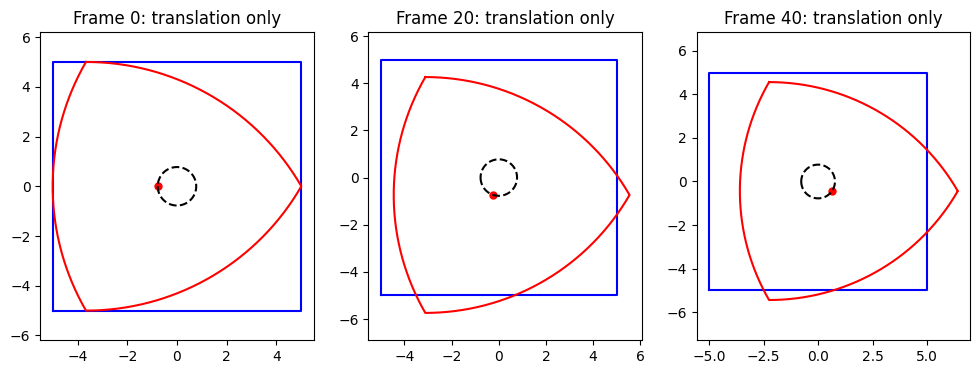

In [30]:
plt.figure(figsize=(12, 4))
N_frames = 100
plt.subplot(1, 3, 1)
draw_frame_translation(r=r, N_frames=N_frames, frame=0)
plt.subplot(1, 3, 2)
draw_frame_translation(r=r, N_frames=N_frames, frame=20)
plt.subplot(1, 3, 3)
draw_frame_translation(r=r, N_frames=N_frames, frame=40)

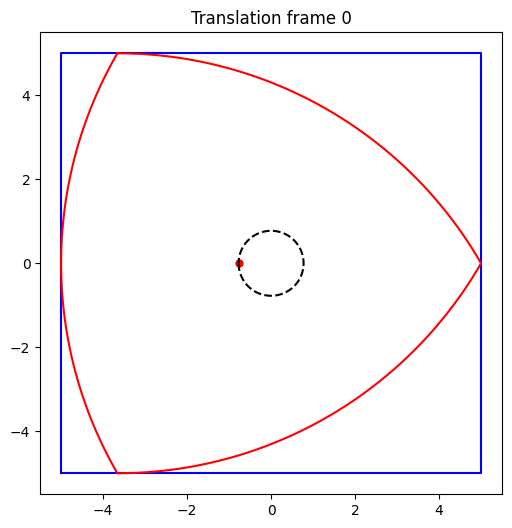

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
N_frames = 100
n_local = 3
N_side = 100
square_local = np.array([
    [-r / 2, -r / 2],
    [r / 2, -r / 2],
    [r / 2, r / 2],
    [-r / 2, r / 2],
    [-r / 2, -r / 2],
])
R_local = r / (2 * np.sin(np.pi / n_local))
shift_local = np.array([R_local - r / 2, 0.0])
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift_local[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
relo_matrix_local = regular_polygon_relo(n=n_local, center=np.array([0.0, 0.0]), r=r, N=N_side)

def update_translation(frame):
    ax.clear()
    frame_center = center_frame[frame]   # center of the Relo triangle for this frame
    relo_frame = relo_matrix_local + frame_center
    ax.plot(square_local[:, 0], square_local[:, 1], 'b-')
    ax.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    ax.plot(frame_center[0], frame_center[1], 'r.', markersize=10)
    ax.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    ax.set_aspect('equal')
    ax.set_title(f'Translation frame {frame}')

anim_translation = animation.FuncAnimation(fig, update_translation, frames=N_frames, interval=50, blit=False)

## Задание 5.3. Анимация качения треугольника Рело

Добавим вращательное движение по часовой стрелке на угол `θ` при одновременно поступательном движении центра по окружности.

In [32]:
rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

print('rotate_matrix(pi) =')
print(rotate_matrix(np.pi))

rotate_matrix(pi) =
[[-1.0000000e+00  1.2246468e-16]
 [-1.2246468e-16 -1.0000000e+00]]


Text(0.5, 1.0, 'Вращение треугольника Рело на π/3 по часовой стрелке')

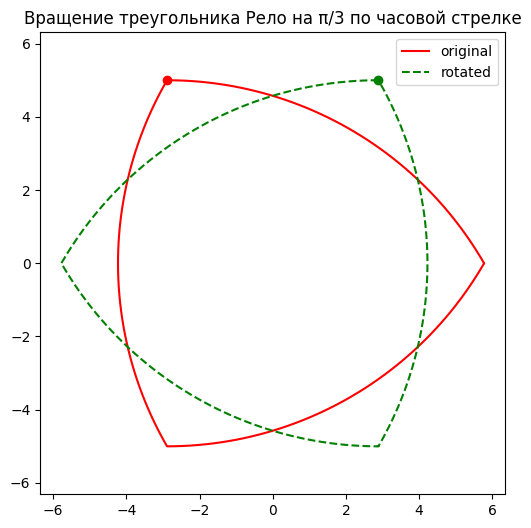

In [33]:
theta = np.pi / 3
matrix = rotate_matrix(theta)
relo_matrix_rotated = np.array([np.dot(matrix, row) for row in relo_matrix])

plt.figure(figsize=(6, 6))
plt.plot(relo_matrix[:, 0], relo_matrix[:, 1], 'r-', label='original')
plt.plot(relo_matrix_rotated[:, 0], relo_matrix_rotated[:, 1], 'g--', label='rotated')
plt.plot(relo_matrix[0, 0], relo_matrix[0, 1], 'ro')
plt.plot(relo_matrix_rotated[0, 0], relo_matrix_rotated[0, 1], 'go')
plt.axis('equal')
plt.legend()
plt.title('Вращение треугольника Рело на π/3 по часовой стрелке')

In [34]:
def draw_frame_roll(r: float, N_frames: int, frame: int = 0) -> None:
    """Draw a single rolling frame of the Relo triangle.

    Parameters
    ----------
    r : float
        Width of the Relo triangle.
    N_frames : int
        Total number of animation frames.
    frame : int, optional
        Frame index to display, by default 0.
    """
    n_local = 3
    N_side = 100
    center_local = np.array([0.0, 0.0])
    square_local = np.array([
        [-r / 2, -r / 2],
        [r / 2, -r / 2],
        [r / 2, r / 2],
        [-r / 2, r / 2],
        [-r / 2, -r / 2],
    ])
    R_local = r / (2 * np.sin(np.pi / n_local))
    shift_local = np.array([R_local - r / 2, 0.0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift_local[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    theta = np.linspace(0, 2 * np.pi / 3, N_frames)
    relo_matrix_local = regular_polygon_relo(n=n_local, center=center_local, r=r, N=N_side)
    matrix = rotate_matrix(theta[frame])
    relo_rotated = np.array([np.dot(matrix, row) for row in relo_matrix_local])
    relo_frame = relo_rotated + center_frame[frame]

    plt.plot(square_local[:, 0], square_local[:, 1], 'b-')
    plt.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    plt.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)
    plt.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    plt.axis('equal')
    plt.title(f'Frame {frame}: rolling')

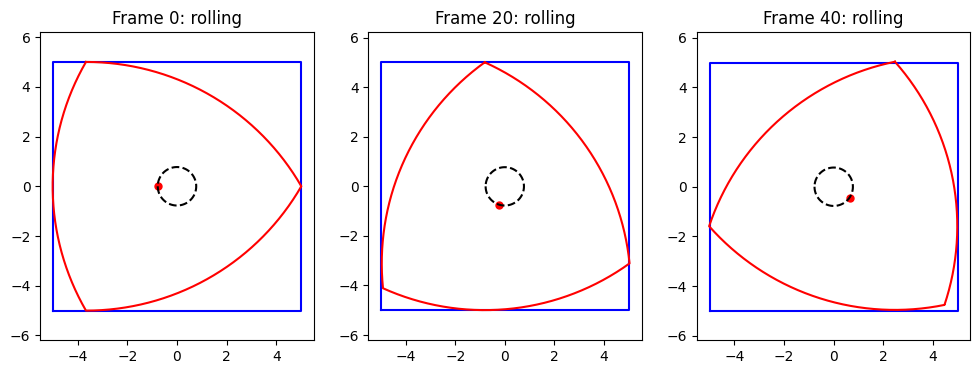

In [35]:
plt.figure(figsize=(12, 4))
N_frames = 100
plt.subplot(1, 3, 1)
draw_frame_roll(r=r, N_frames=N_frames, frame=0)
plt.subplot(1, 3, 2)
draw_frame_roll(r=r, N_frames=N_frames, frame=20)
plt.subplot(1, 3, 3)
draw_frame_roll(r=r, N_frames=N_frames, frame=40)

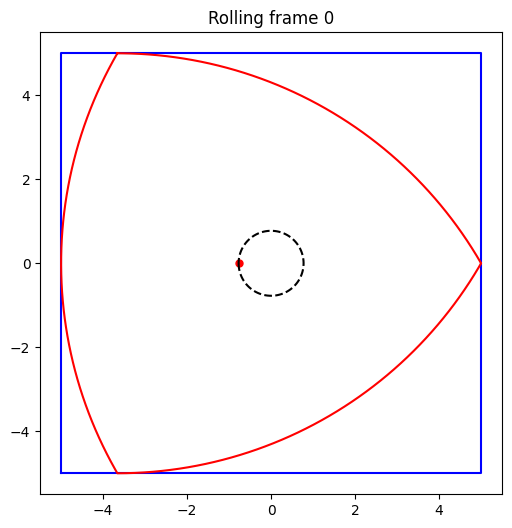

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))
N_frames = 100
n_local = 3
N_side = 100
square_local = np.array([
    [-r / 2, -r / 2],
    [r / 2, -r / 2],
    [r / 2, r / 2],
    [-r / 2, r / 2],
    [-r / 2, -r / 2],
])
R_local = r / (2 * np.sin(np.pi / n_local))
shift_local = np.array([R_local - r / 2, 0.0])
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift_local[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
theta = np.linspace(0, 2 * np.pi / 3, N_frames)
relo_matrix_local = regular_polygon_relo(n=n_local, center=np.array([0.0, 0.0]), r=r, N=N_side)

def update_roll(frame):
    ax.clear()
    matrix = rotate_matrix(theta[frame])
    relo_rotated = np.array([np.dot(matrix, row) for row in relo_matrix_local])
    relo_frame = relo_rotated + center_frame[frame]
    ax.plot(square_local[:, 0], square_local[:, 1], 'b-')
    ax.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    ax.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)
    ax.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    ax.set_aspect('equal')
    ax.set_title(f'Rolling frame {frame}')

anim_roll = animation.FuncAnimation(fig, update_roll, frames=N_frames, interval=50, blit=False)

In [ ]:
from IPython.display import HTML, display

r = globals().get("r", 10.0)
N_frames = 100
n_local = 3
N_side = 100
square_local = np.array([
    [-r / 2, -r / 2],
    [r / 2, -r / 2],
    [r / 2, r / 2],
    [-r / 2, r / 2],
    [-r / 2, -r / 2],
])
R_local = r / (2 * np.sin(np.pi / n_local))
shift_local = np.array([R_local - r / 2, 0.0])
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift_local[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
relo_matrix_local = regular_polygon_relo(n=n_local, center=np.array([0.0, 0.0]), r=r, N=N_side)

fig_t, ax_t = plt.subplots(figsize=(6, 6))
def update_translation(frame):
    ax_t.clear()
    frame_center = center_frame[frame]
    relo_frame = relo_matrix_local + frame_center
    ax_t.plot(square_local[:, 0], square_local[:, 1], 'b-')
    ax_t.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    ax_t.plot(frame_center[0], frame_center[1], 'r.', markersize=10)
    ax_t.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    ax_t.set_aspect('equal')
    ax_t.set_title(f'Translation frame {frame}')
anim_translation = animation.FuncAnimation(fig_t, update_translation, frames=N_frames, interval=50, blit=False)

theta = np.linspace(0, 2 * np.pi / 3, N_frames)
relo_matrix_local = regular_polygon_relo(n=n_local, center=np.array([0.0, 0.0]), r=r, N=N_side)

fig_r, ax_r = plt.subplots(figsize=(6, 6))
def rotate_matrix(theta):
    return np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

def update_roll(frame):
    ax_r.clear()
    matrix = rotate_matrix(theta[frame])
    relo_rotated = np.array([np.dot(matrix, row) for row in relo_matrix_local])
    relo_frame = relo_rotated + center_frame[frame]
    ax_r.plot(square_local[:, 0], square_local[:, 1], 'b-')
    ax_r.plot(relo_frame[:, 0], relo_frame[:, 1], 'r-')
    ax_r.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)
    ax_r.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    ax_r.set_aspect('equal')
    ax_r.set_title(f'Rolling frame {frame}')
anim_roll = animation.FuncAnimation(fig_r, update_roll, frames=N_frames, interval=50, blit=False)

display(HTML(anim_translation.to_jshtml()))
display(HTML(anim_roll.to_jshtml()))
